# Generate manuscript figures

In [1]:
# import
import numpy as np; import pandas as pd
import glob; import os; from os.path import exists; import sys; import platform
from scipy import stats
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib; import seaborn as sns
from datetime import datetime
import re
import scipy
print(scipy.__version__)
from matplotlib import colors

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
1.13.1


In [2]:
# Set paths
current_directory = os.getcwd()
base_dir = f'{os.path.dirname(current_directory)}/'
data_dir = f'{base_dir}Source_Data/'

space = 'fsaverage' # 'fsaverage' or 'fsnative'
fig_dir = f'{base_dir}/Figs/{space}/'
sessions = ['ses-1','ses-2','ses-3','ses-4','ses-5']

In [3]:
# Set plotting parameters
print(plt.rcParams["figure.figsize"])
plt.rcParams["figure.figsize"] = (4, 3.5)
print("new figure size is: ", plt.rcParams["figure.figsize"])
pd.set_option('display.max_columns', 500,'display.max_rows',None) 

[6.4, 4.8]
new figure size is:  [4.0, 3.5]


In [16]:
# Load dataframes
long_filename      = f'{data_dir}ROI2ROI_{space}_long.csv'
dice_filename      = f'{data_dir}Dice_fsnative_long.csv'
conn_dist_filename = f'{data_dir}Connectome_fsaverage_long.csv'

all_data_long= pd.read_csv(long_filename, index_col=0)
dice_data = pd.read_csv(dice_filename,index_col=0)

In [5]:
# create another column to control order of sessions
all_data_long['session_cat'] = pd.Categorical(all_data_long['session'], categories=sessions, ordered=True)

# Recreate list variables from dataframe in order to use these lists in query
subs_wo_VWFA2_ses2 = all_data_long.query("~hasVWFA2_ses2")['sub_id'].unique()
print(len(subs_wo_VWFA2_ses2))

28


In [6]:
# Set plotting parameters
all_colors = [(1, 145/255, 0), (210/255, 190/255, 1),(160/255, 255/255, 160/255), (30/255, 220/255, 75/255)]
color_dict = {'VWFA-1':(1, 145/255, 0),
             'VWFA-2':(210/255, 190/255, 1),
             'FFA-1':(160/255, 255/255, 160/255),
             'FFA-2':(30/255, 220/255, 75/255)}

word_colors = [(1, 145/255, 0), (210/255, 190/255, 1)]
face_colors = [(160/255, 255/255, 160/255), (30/255, 220/255, 75/255)]
# eight shades to separate subjects with and without VWFA
all_colors_8 = [(1, 0.5686274509803921, 0), (1, 0.38, 0.0),
                 (0.8235294117647058, 0.7450980392156863, 1),(0.7, 0.43, 1),
                 (0.6274509803921569, 1.0, 0.6274509803921569),(0.4079, 0.65, 0.4079),
                 (0.11764705882352941, 0.8627450980392157, 0.29411764705882354),(0.0764, 0.5608, 0.1912)]

vROI_order = ['VWFA-1','VWFA-2','FFA-1','FFA-2'] # set this for plotting

darker_colors_4 = [tuple(c * 0.85 for c in color) for color in all_colors]
darker_colors_8 = [tuple(c * 0.85 for c in color) for color in all_colors_8]

# Set these parameters to remove axes
custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(style="ticks", rc=custom_params)

# order for figures:
session_order = ['ses-1','ses-2','ses-3','ses-4','ses-5']
group_order = ['intervention','control_dys','control_typ']

group_palette = {"intervention": "tomato",
                 "control_dys":"darkgray",
                 "control_typ":"gray"}

time_labels = ["Baseline", "Pre", "Post", "6m", "12m"]

# Add another column with readable names for figures
tp_dict_labels = {'Baseline': 'Baseline',
                'Pre-Intervention': 'Pre',
                'Post-Intevention': 'Post',
                '6 Month Follow-Up': '6mo',
                '12 Month Follow-Up':'12mo'}

ses_dict_labels = {'ses-1': 'Baseline',
                'ses-2': 'Pre',
                'ses-3': 'Post',
                'ses-4': '6mo',
                'ses-5':'12mo',
                  'baseline':'Baseline',
                  'Baseline' : 'Baseline'}


all_data_long['time_labels'] = all_data_long['Visit'].map(tp_dict_labels)


# Figure 1: Pre-intervention

212
53
subjects without VWFA2: 20
subjects with VWFA2: 33
/Users/mayayablonski/git//Figs/fsaverage/ROI2ROI_fsaverage_bar_point_dys_VWFA2status_median_se1_IFC_ses-2_v2.png


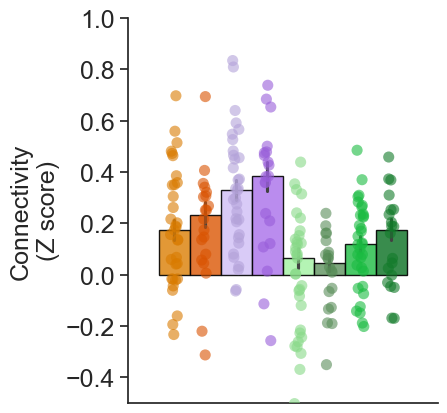

In [8]:
# Figure 1D
# Pre-intervention: Compare subjects with and without VWFA2

fROI = 'IFC'
my_group = 'dys' # split subjects with dyslexia based on their VWFA2 status
my_estimator = 'median'
my_ses = 'ses-2'
saveFig = False

plot_data_long = all_data_long.query("session == @my_ses and ~FC.isnull() and ROI2 == @fROI")
if my_group in all_data_long['group'].unique():
    plot_data_long = all_data_long.query("session == @my_ses and ROI2 == @fROI and ~FC.isnull() and group == @my_group")
elif my_group in all_data_long['reading_group'].unique():
    plot_data_long = all_data_long.query("session == @my_ses and ROI2 == @fROI and ~FC.isnull() and reading_group == @my_group")

print(len(plot_data_long))
print(len(plot_data_long['sub_id'].unique()))
print(f"subjects without VWFA2: {len(plot_data_long.query('~hasVWFA2_ses2')['sub_id'].unique())}")
print(f"subjects with VWFA2: {len(plot_data_long.query('hasVWFA2_ses2')['sub_id'].unique())}")

fig, ax = plt.subplots(figsize =(4, 5))

sns.barplot(x="time_labels", y="FC", estimator = my_estimator,errorbar = ('se', 1),
            hue="ROI1_VWFA2_status", palette=all_colors_8 ,alpha=0.9, axes = ax,edgecolor='black',
            data=plot_data_long)

# create colors that are 15% darker so they stand out more on the bars
darker_colors_8 = [tuple(c * 0.85 for c in color) for color in all_colors_8]

sns.stripplot(x="time_labels", y="FC",
            hue="ROI1_VWFA2_status", palette = darker_colors_8,jitter=0.1,dodge=1,alpha=0.6,size=8,axes = ax,
            data=plot_data_long, legend=False)

plt.xticks([])
plt.yticks(fontsize=18)
plt.xlabel('', fontsize=18)
plt.ylabel("Connectivity\n(Z score)", fontsize=18)
plt.ylim([-0.5,1])
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)

#ax.legend(ncol=4)
ax.get_legend().remove()
#plt.title(fROI, fontsize = 14)
figPath = f'{fig_dir}ROI2ROI_{space}_bar_point_{my_group}_VWFA2status_{my_estimator}_se1_{fROI}_{my_ses}.png'
print(figPath)
if saveFig:
    plt.savefig(figPath,bbox_inches='tight',dpi=300)

subjects without VWFA2: 20
subjects with VWFA2: 33
TtestResult(statistic=0.036132702435854265, pvalue=0.9713495744308395, df=41.55267046749941)
/Users/mayayablonski/git//Figs/fsaverage/ROI2ROI_fsaverage_bar_point_dys_VWFA2status_median_se1_Delta_IFC_ses-2_v2.png


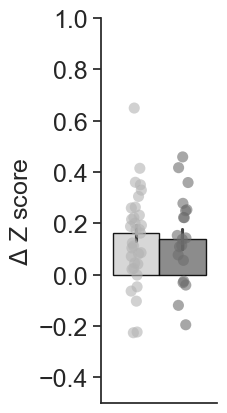

In [9]:
#Figure 1E:
# to look within individual, plot the difference between VWFA1-VWFA2 (DeltaIFC)
fROI = 'IFC'
my_group = 'dys' 
my_estimator = 'median'
my_ses = 'ses-2'
saveFig = False
roi_presence_palette = ['lightgray','gray']
roi_presence_palette_rgb = [colors.to_rgb(color) for color in roi_presence_palette]
darker_presence = [tuple(c * 0.85 for c in color) for color in roi_presence_palette_rgb]

if my_group in all_data_long['group'].unique():
    plot_data_long = all_data_long.query("session == @my_ses and ROI2 == @fROI and ~FC.isnull() and group == @my_group")
elif my_group in all_data_long['reading_group'].unique():
    plot_data_long = all_data_long.query("session == @my_ses and ROI2 == @fROI and ~FC.isnull() and reading_group == @my_group")

# need to drop the duplicates when looking at delta 
plot_data_long = plot_data_long.drop_duplicates('sub_id')

print(f"subjects without VWFA2: {len(plot_data_long.query('~hasVWFA2_ses2')['sub_id'].unique())}")
print(f"subjects with VWFA2: {len(plot_data_long.query('hasVWFA2_ses2')['sub_id'].unique())}")

t_test_res = stats.ttest_ind(plot_data_long.query('hasVWFA2_ses2')[f"Delta_{fROI}"],plot_data_long.query('~hasVWFA2_ses2')[f"Delta_{fROI}"],
                             equal_var=False)

print(t_test_res)

fig, ax = plt.subplots(figsize =(1.5, 5))

sns.barplot(x="time_labels", y=f"Delta_{fROI}", estimator = my_estimator,errorbar = ('se', 1),edgecolor='black',
            hue="VWFA2_status", palette = roi_presence_palette, alpha=0.9, axes = ax,
            data=plot_data_long)

sns.stripplot(x="time_labels", y=f"Delta_{fROI}",
            hue="VWFA2_status", palette = darker_presence,jitter=0.1,dodge=1,alpha=0.6,size=8,axes = ax,
            data=plot_data_long, legend=False)

plt.xticks([])
plt.xlabel('', fontsize=18)
plt.ylabel("$\\Delta $ Connectivity\n(Z score)", fontsize=16)
plt.ylabel("$\\Delta $ Z score", fontsize=18)
plt.ylim([-0.5,1])
plt.yticks(fontsize=18)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
ax.get_legend().remove()

figPath = f'{fig_dir}ROI2ROI_{space}_bar_point_{my_group}_VWFA2status_{my_estimator}_se1_Delta_{fROI}_{my_ses}_v2.png'
print(figPath)
if saveFig:
    plt.savefig(figPath,bbox_inches='tight',dpi=300)

288
72
typical readers: 19
dyslexic readers: 53
/Users/mayayablonski/git//Figs/fsaverage/ROI2ROI_fsaverage_bar_point_typ_dys_median_se1_IFC_ses-2_v2.png


/var/folders/d8/3w1f9g4n2zg37678k4g3p5yh0000gn/T/ipykernel_62525/229030129.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_data_long['ROI1_readinggroup'] = (plot_data_long['ROI1'] + '_' + plot_data_long['reading_group'])


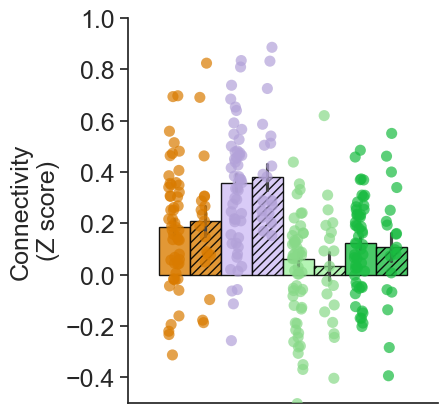

In [10]:
# Figure 1B
# Pre-intervention: Compare in the same plot typical readers and dyslexic readers

fROI = 'IFC'
my_estimator = 'median'
my_ses = 'ses-2'
saveFig = False
wLegend = False
# now we have 3 target ROIs in fsaverage
plot_data_long = all_data_long.query("session == @my_ses and ROI2 == @fROI and ~FC.isnull()")

print(len(plot_data_long))
print(len(plot_data_long['sub_id'].unique()))
N_typ = len(plot_data_long.query('reading_group == "typ"')['sub_id'].unique())
N_dys = len(plot_data_long.query('reading_group == "dys"')['sub_id'].unique())
print(f"typical readers: {N_typ}")
print(f"dyslexic readers: {N_dys}")

# we need to create a column combining group and ROI so we can use the colors we want
plot_data_long['ROI1_readinggroup'] = (plot_data_long['ROI1'] + '_' + plot_data_long['reading_group'])
double_colors = [color for color in all_colors for _ in range(2)]

fig, ax = plt.subplots(figsize =(4, 5))

allbars = sns.barplot(x="time_labels", y="FC", estimator = my_estimator,errorbar = ('se', 1),
            hue="ROI1_readinggroup",#fill = False,
            palette=double_colors,edgecolor='black',
            alpha=0.9, axes = ax,
            data=plot_data_long)

for bar_id, bar in enumerate(allbars.patches):
    if bar_id % 2 == 1:
        bar.set_hatch('////')

# create colors that are 15% darker so they stand out more on the bars
darker_colors = [tuple(c * 0.85 for c in color) for color in double_colors]

sns.stripplot(x="time_labels", y="FC",
            hue="ROI1_readinggroup", palette = darker_colors,jitter=0.15,dodge=1,alpha=0.7,size=8,axes = ax,
            data=plot_data_long, legend=False)

plt.xticks([])
plt.yticks(fontsize=18)
plt.xlabel('', fontsize=16)
plt.ylabel("Connectivity\n(Z score)", fontsize=18)
plt.ylim([-0.5,1])
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
ax.legend(ncol=2)

figPath = f'{fig_dir}ROI2ROI_{space}_bar_point_typ_dys_{my_estimator}_se1_{fROI}_{my_ses}_v2.png'
if wLegend:
    figPath = figPath.replace('.png','_legend.png')
else:
    ax.get_legend().remove()
print(figPath)
if saveFig:
    plt.savefig(figPath,bbox_inches='tight',dpi=300)

TtestResult(statistic=1.5417819814690985, pvalue=0.1306320762812662, df=41.978122638155625)
/Users/mayayablonski/git//Figs/fsaverage/ROI2ROI_fsaverage_bar_point_typ_dys_median_se1_Delta_IFC_ses-2_v2.png


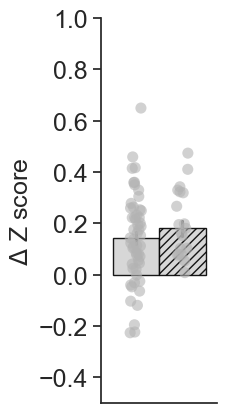

In [11]:
#Figure 1C
# to look within individual, plot the difference between VWFA1-VWFA2 (DeltaIFC)
fROI = 'IFC'
my_estimator = 'median'
my_ses = 'ses-2'
saveFig = False

dystyp_palette = ['lightgray','lightgray']
dystyp_palette_rgb = [colors.to_rgb(color) for color in dystyp_palette]
darker_dystyp = [tuple(c * 0.85 for c in color) for color in dystyp_palette_rgb]

plot_data_long = all_data_long.query("session == @my_ses and ROI2 == @fROI and ~FC.isnull()")

# need to drop the duplicates when looking at delta 
plot_data_long = plot_data_long.drop_duplicates('sub_id')


t_test_res = stats.ttest_ind(plot_data_long.query("reading_group == 'typ'")[f"Delta_{fROI}"],
                             plot_data_long.query("reading_group == 'dys'")[f"Delta_{fROI}"],
                             equal_var=False)

print(t_test_res)

fig, ax = plt.subplots(figsize =(1.5, 5))

allbars = sns.barplot(x="time_labels", y=f"Delta_{fROI}", estimator = my_estimator,errorbar = ('se', 1),edgecolor='black',
            hue="reading_group", palette = dystyp_palette, alpha=0.9, axes = ax,
            data=plot_data_long)

for bar_id, bar in enumerate(allbars.patches):
    if bar_id % 2 == 1:
        bar.set_hatch('////')
        
sns.stripplot(x="time_labels", y=f"Delta_{fROI}",
            hue="reading_group", palette = darker_dystyp,jitter=0.1,dodge=1,alpha=0.6,size=8,axes = ax,
            data=plot_data_long, legend=False)

plt.xticks([])
plt.xlabel('', fontsize=18)
plt.ylabel("$\\Delta $ Z score", fontsize=18)
plt.ylim([-0.5,1])
plt.yticks(fontsize=18)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
ax.get_legend().remove()

figPath = f'{fig_dir}ROI2ROI_{space}_bar_point_typ_dys_{my_estimator}_se1_Delta_{fROI}_{my_ses}_v2.png'
print(figPath)
if saveFig:
    plt.savefig(figPath,bbox_inches='tight',dpi=300)

# Figure 2: Longitudinal analysis

In [12]:
# To plot baseline data we need to create a single datapoint for baseline that is 
# the average of ses-1 and ses-2 - to accurately represent the statistical tests
# otherwise longitudinal data will have twice as many datapoints in 'baseline' session (counting both ses1 and ses2 for subjects that have both)
# which will not be represented correctly in lineplots
longitudinal_data = all_data_long[["sub_id","sesb","ROI1","ROI2","FC","Delta_IFC"]].groupby(["sub_id","sesb","ROI1","ROI2"]).mean().reset_index()
grouping_df = all_data_long[['sub_id','group','reading_group','age_ses2']].drop_duplicates(keep='first')
longitudinal_data = longitudinal_data.merge(grouping_df,on = ['sub_id'],how='left')
longitudinal_data.head()

,sub_id,sesb,ROI1,ROI2,FC,Delta_IFC,group,reading_group,age_ses2
0,sub-001,baseline,FFA-1,IFC,0.314559,-0.103185,control_dys,dys,10.083333
1,sub-001,baseline,FFA-2,IFC,0.369970,-0.103185,control_dys,dys,10.083333
2,sub-001,baseline,VWFA-1,IFC,0.472382,-0.103185,control_dys,dys,10.083333
3,sub-001,baseline,VWFA-2,IFC,0.369197,-0.103185,control_dys,dys,10.083333
4,sub-001,ses-3,FFA-1,IFC,0.238069,-0.005262,control_dys,dys,10.083333


## Figure 2b: Bar graphs FC of ventral ROIs

In [ ]:
# Single session
fROI = 'IFC'
my_group = 'intervention'
my_estimator = 'median'
saveFig = False
wLegend = False
cur_sessions = ['ses-1','ses-2','ses-3','ses-4','ses-5']

for ses in cur_sessions:
    plot_data_long = all_data_long.query("ROI2 == @fROI and session == @ses and group == @my_group")
    
    print(len(plot_data_long))
    print(len(plot_data_long['sub_id'].unique()))
    filename = f'ROI2ROI_{space}_bar_point_{my_group}_{my_estimator}_{fROI}_{ses}.png'
    
    fig, ax = plt.subplots(figsize =(3, 4))
    
    sns.barplot(x="time_labels", y="FC", estimator = my_estimator,errorbar = ('se', 1),hue_order = vROI_order,
                hue="ROI1", palette=all_colors ,alpha=0.9, axes = ax,edgecolor='black',
                data=plot_data_long)
    
    sns.stripplot(x="time_labels", y="FC",
                hue="ROI1", palette = darker_colors_4,jitter=0.1,dodge=1,alpha=0.6,size=8,hue_order = vROI_order,
                  axes = ax,
                data=plot_data_long, legend=False)
    
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    plt.xlabel('', fontsize=18)
    plt.ylabel("Connectivity\n(Z score)", fontsize=18)
    plt.ylim([-0.5,1])
    if wLegend:
        
        plt.legend(ncol=4, bbox_to_anchor=(1.05, 1), loc='upper center', borderaxespad=0, frameon = False)
        
        filename = str.replace(filename,'.png','_legend.png')
    else:
        ax.get_legend().remove()
    print(filename)
    figPath = f'{fig_dir}/{filename}'
    if saveFig:
        plt.savefig(figPath,bbox_inches='tight',dpi=300)

/Users/mayayablonski/git//Figs/fsaverage/ROI2ROI_fsaverage_time_intervention_median_se1_IFC.png


/var/folders/d8/3w1f9g4n2zg37678k4g3p5yh0000gn/T/ipykernel_62525/2813691356.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(newticklabels)


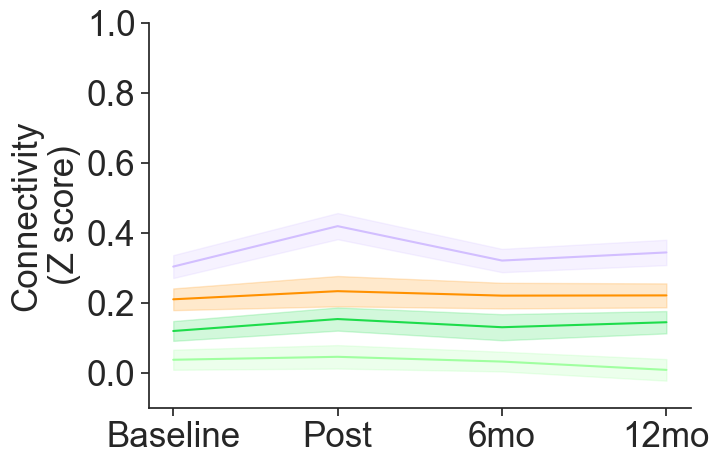

In [13]:
# Figure 2C:
# FC over time
saveFig = False

# Plot FC over time 
my_group = 'intervention' 
fROI = 'IFC'
my_estimator = 'median'

# to make sure the font size is exactly the same across all figures 
bar_width = 5 # this is the width of the bar plot
current_width = 7

font_scale = current_width / bar_width

plot_data_long = longitudinal_data.query("ROI2 == @fROI and group == @my_group")

fig, ax = plt.subplots(figsize =(current_width, 5))
sns.lineplot(data = plot_data_long,x = 'sesb',y='FC',hue = 'ROI1',palette = all_colors,hue_order = vROI_order,
            estimator = my_estimator,errorbar = ('se', 1),ax=ax)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
plt.ylim([-0.1, 1])
plt.xticks(fontsize=18 * font_scale)
plt.yticks(fontsize=18 * font_scale)
plt.xlabel('', fontsize=18)

xticklabels = [t.get_text() for t in ax.get_xticklabels()]
newticklabels = [ses_dict_labels[xlabel] for xlabel in xticklabels]
ax.set_xticklabels(newticklabels)
plt.ylabel("Connectivity\n(Z score)", fontsize=18 * font_scale)
ax.get_legend().remove()
figPath = f'{fig_dir}ROI2ROI_{space}_time_{my_group}_{my_estimator}_se1_{fROI}.png'
print(figPath)
if saveFig:
    plt.savefig(figPath,bbox_inches='tight',dpi=300)
    

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


/Users/mayayablonski/git//Figs/fsaverage/ROI2ROI_fsaverage_time_intervention_VWFA-2_indiv_IFC_VWFA-2.png


/var/folders/d8/3w1f9g4n2zg37678k4g3p5yh0000gn/T/ipykernel_62525/2499439051.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(newticklabels)


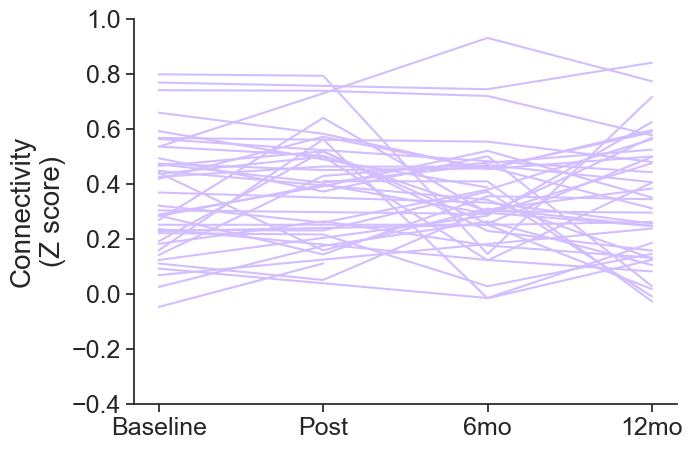

In [14]:
# Figure 2C 
# FC over time - SPAGHETTI PLOT individual subjects
saveFig = False

# Plot FC over time
my_group = 'intervention' 
fROI = 'IFC'; vROI = 'VWFA-2'
my_estimator = 'median'

plot_data_long = longitudinal_data.query("ROI2 == @fROI and group == @my_group")

fig, ax = plt.subplots(figsize =(7, 5))
sns.lineplot(data = plot_data_long.query("ROI1 == @vROI"),x = 'sesb',y='FC',units='sub_id', color = color_dict[vROI],
            estimator = None,
            ax=ax)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
plt.ylim([-0.4, 1])
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.xlabel('', fontsize=18)

xticklabels = [t.get_text() for t in ax.get_xticklabels()]
newticklabels = [ses_dict_labels[xlabel] for xlabel in xticklabels]
ax.set_xticklabels(newticklabels)
plt.ylabel("Connectivity\n(Z score)", fontsize=20)
ax.get_legend().remove()
figPath = f'{fig_dir}ROI2ROI_{space}_time_{my_group}_{vROI}_indiv_{fROI}_{vROI}.png'
print(figPath)
if saveFig:
    plt.savefig(figPath,bbox_inches='tight',dpi=300)
    

## Figure 4: Connectome Distance measures

In [17]:
all_data_dist = pd.read_csv(conn_dist_filename, index_col=0)
all_data_dist['pearson_dis'] = 1- all_data_dist['pearson']
all_data_dist.head()

,sub_id,session,ROI_pair,ROI1,ROI2,cosine,pearson,MRI_weeks_ses2,age_ses2,exclude,group,inter,reading_group,Gender,age,Visit,meanFD,hasVWFA2_ses2,VWFA2_status,hasVWFA2_combined,sesb,session_cat,pearson_dis
0,sub-001,ses-2,FFA-1_FFA-2,FFA-1,FFA-2,0.049650,0.949320,0.0,10.083333,0.0,control_dys,controls,dys,Male,10.083333,Pre-Intervention,0.181029,True,hasVWFA2ses2,True,baseline,ses-2,0.050680
1,sub-001,ses-2,FFA-1_VWFA-1,FFA-1,VWFA-1,0.110105,0.888461,0.0,10.083333,0.0,control_dys,controls,dys,Male,10.083333,Pre-Intervention,0.181029,True,hasVWFA2ses2,True,baseline,ses-2,0.111539
2,sub-001,ses-2,FFA-1_VWFA-2,FFA-1,VWFA-2,0.141031,0.856047,0.0,10.083333,0.0,control_dys,controls,dys,Male,10.083333,Pre-Intervention,0.181029,True,hasVWFA2ses2,True,baseline,ses-2,0.143953
3,sub-001,ses-2,FFA-2_FFA-1,FFA-2,FFA-1,0.049650,0.949320,0.0,10.083333,0.0,control_dys,controls,dys,Male,10.083333,Pre-Intervention,0.181029,True,hasVWFA2ses2,True,baseline,ses-2,0.050680
4,sub-001,ses-2,FFA-2_VWFA-1,FFA-2,VWFA-1,0.102701,0.895818,0.0,10.083333,0.0,control_dys,controls,dys,Male,10.083333,Pre-Intervention,0.181029,True,hasVWFA2ses2,True,baseline,ses-2,0.104182


In [18]:
distance_dict = {'dist':'Euclidean Distance',
                'cosine': 'Cosine Distance',
                'angle': 'Angle (degrees)',
                'pearson': 'Similarity (r)',
                'pearson_dis': "Pearson's Distance"}
all_data_dist['time_labels'] = all_data_dist['Visit'].map(tp_dict_labels)

TtestResult(statistic=0.36124804548703454, pvalue=0.7197728707025367, df=40.913260817373526)
/Users/mayayablonski/git//Figs/fsaverage/Distance_fsaverage_boxplot_VWFA2status_cosine_VWFA-2_VWFA-1_ses-2.png


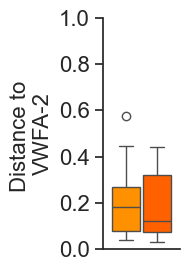

In [19]:
# Figure 4C: 
# Plot distance between VWFA-1 and VWFA-2 in baseline between groups
src_ROI = 'VWFA-2'; trg_ROI = 'VWFA-1'
dist_metric = 'cosine'
saveFig = False

fig, ax = plt.subplots(figsize =(1, 3))
plot_df = all_data_dist.query("ROI1 == @src_ROI and ROI2 == @trg_ROI and session == 'ses-2' and reading_group == 'dys' and exclude ==0")

sns.boxplot(data = plot_df, x = 'time_labels',y = dist_metric, hue = 'VWFA2_status', saturation=1, gap=0.1,
            palette = [all_colors_8[0],all_colors_8[1]],ax=ax)

t_test_res = stats.ttest_ind(plot_df.query("hasVWFA2_ses2")[dist_metric],
                             plot_df.query("~hasVWFA2_ses2")[dist_metric],
                             equal_var=False)
print(t_test_res)
if dist_metric == 'dist':
    yrange = [0,5]
elif dist_metric == 'cosine':
    yrange = [0,1]
elif dist_metric == 'pearson':
    yrange = [0,1]
elif dist_metric == 'pearson_dis':
    yrange = [0,1]
    
plt.ylim(yrange)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
plt.xticks([])
plt.xlabel('', fontsize=16)
plt.yticks(fontsize=16)
plt.ylabel(f'{distance_dict[dist_metric]}', fontsize=16)
plt.ylabel(f'Distance to \n{src_ROI}', fontsize=16)
ax.get_legend().remove()

figPath = f'{fig_dir}Distance_{space}_boxplot_VWFA2status_{dist_metric}_{src_ROI}_{trg_ROI}_ses-2.png'
print(figPath)
if saveFig:
    plt.savefig(figPath,bbox_inches='tight',dpi=300)

TtestResult(statistic=-0.6363426901254193, pvalue=0.5303661021173085, df=24.872272217234617)
/Users/mayayablonski/git//Figs/fsaverage/Distance_fsaverage_boxplot_dys_typ_cosine_VWFA-2_VWFA-1_ses-2.png


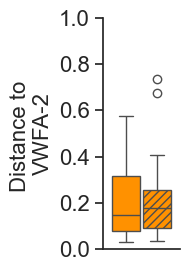

In [20]:
# Figure 4B
# Plot distance between VWFA-1 and VWFA-2 in baseline between groups
src_ROI = 'VWFA-2'; trg_ROI = 'VWFA-1'
dist_metric = 'cosine'
saveFig = False
my_ses = 'ses-2'

fig, ax = plt.subplots(figsize =(1, 3))
plot_df = all_data_dist.query("ROI1 == @src_ROI and ROI2 == @trg_ROI and session == 'ses-2' and exclude ==0")

# sns.stripplot(data = plot_df, x = 'time_labels',y = dist_metric, hue = 'VWFA2_status', dodge=1,alpha=0.6,size=8,
#               palette=['darkgray','darkgray'],ax=ax)
allbars = sns.boxplot(data = plot_df, x = 'time_labels',y = dist_metric, hue = 'reading_group', saturation=1, gap=0.1,
            palette = [color_dict[trg_ROI],color_dict[trg_ROI]],ax=ax)

patch_id = [1,3] # hard-coded based on manually checking the patch ids 
for bar_id, bar in enumerate(allbars.patches):
    if bar_id in patch_id:
        bar.set_hatch('////')
        
t_test_res = stats.ttest_ind(plot_df.query("reading_group == 'dys'")[dist_metric],
                             plot_df.query("reading_group == 'typ'")[dist_metric],
                             equal_var=False)
print(t_test_res)

if dist_metric == 'dist':
    yrange = [0,5]
elif dist_metric == 'cosine':
    yrange = [0,1]
elif dist_metric == 'pearson':
    yrange = [0,1]
elif dist_metric == 'pearson_dis':
    yrange = [0,1]
    
plt.ylim(yrange)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
plt.xticks([])
plt.xlabel('', fontsize=16)
#plt.ylim([-0.5,1])
plt.yticks(fontsize=16)
plt.ylabel(f'{distance_dict[dist_metric]}', fontsize=16)
plt.ylabel(f'Distance to \n{src_ROI}', fontsize=16)

ax.get_legend().remove()

figPath = f'{fig_dir}Distance_{space}_boxplot_dys_typ_{dist_metric}_{src_ROI}_{trg_ROI}_{my_ses}.png'
print(figPath)
if saveFig:
    plt.savefig(figPath,bbox_inches='tight',dpi=300)

In [21]:
color_indices = [0,2,3]
dist_colors = [all_colors[i] for i in color_indices]
dist_order = vROI_order.copy()
dist_order.remove('VWFA-2')



/Users/mayayablonski/git//Figs/fsaverage/Distance_fsaverage_longitudinal_cosine_VWFA-2_median_se1_ses-2.png


/var/folders/d8/3w1f9g4n2zg37678k4g3p5yh0000gn/T/ipykernel_62525/614088149.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(newticklabels)


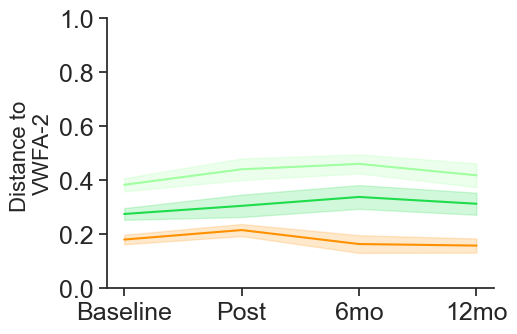

In [22]:
# Figure 4D
# Logitudinal change in distance over time within intervention group

src_ROI = 'VWFA-2'
dist_metric = 'cosine'
saveFigs = False

my_estimator = 'median'
plot_df = all_data_dist.query("ROI1 == @src_ROI and group == 'intervention'")

fig, ax = plt.subplots(figsize =(5, 3.5))
sns.lineplot(data = plot_df,x = 'sesb',y = dist_metric, hue = 'ROI2',estimator = my_estimator,errorbar = ('se',1),
              palette = dist_colors, hue_order = dist_order,ax=ax)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
if dist_metric == 'dist':
    yrange = [0,5]
elif dist_metric == 'cosine':
    yrange = [0,1]
elif dist_metric == 'pearson':
    yrange = [0,1]
elif dist_metric == 'dissimilarity':
    yrange = [0,1]
    
plt.ylim(yrange)
plt.ylabel(f'{distance_dict[dist_metric]}', fontsize=18)
plt.ylabel(f'Distance to \n{src_ROI}', fontsize=16)
ax.get_legend().remove()

xticklabels = [t.get_text() for t in ax.get_xticklabels()]
newticklabels = [ses_dict_labels[xlabel] for xlabel in xticklabels]
ax.set_xticklabels(newticklabels)

plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.xlabel('', fontsize=18)

figPath = f'{fig_dir}Distance_{space}_longitudinal_{dist_metric}_{src_ROI}_{my_estimator}_se1_{my_ses}.png'
print('\n');print(figPath)
if saveFig:
    plt.savefig(figPath,bbox_inches='tight',dpi=300)


# Dice coefficient

65
/Users/mayayablonski/git//Figs/fsaverage/Dice_DC_fsaverage_all_N65_mean_se1_IFC_0.1.png


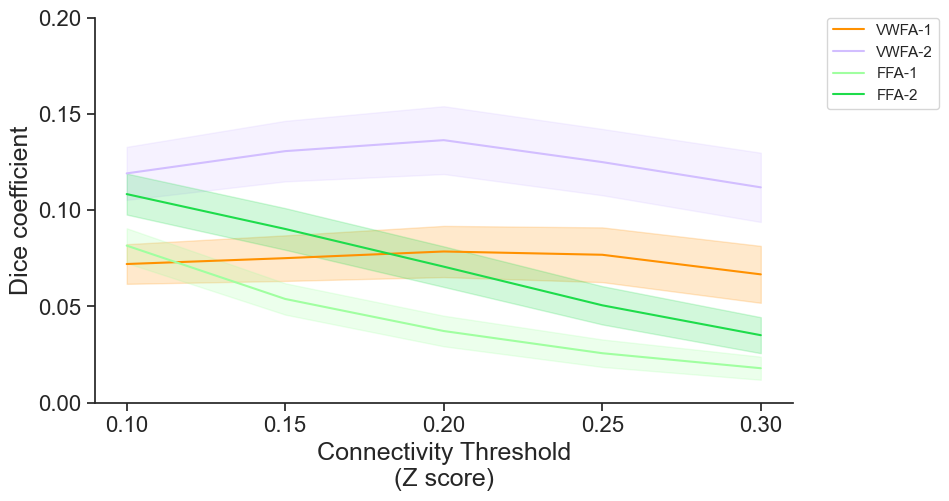

In [23]:
# Figure 5B
# DICE across thresholds
saveFig = False
my_group = 'all' 
fROI = 'IFC'
my_estimator = 'mean'
dice_var = 'DC' # DC or JC - DC is more intuitive, JC is slightly less biased by size

if my_group in dice_data['group'].unique():
    plot_data_long = dice_data.query("ROI2 == @fROI and group == @my_group")
elif my_group == 'dys':
    plot_data_long = dice_data.query("ROI2 == @fROI and reading_group == @my_group")
elif my_group == 'all':
    plot_data_long = dice_data.query("ROI2 == @fROI")
else:
    print("Cant recognize group\n Check code")
    saveFig = False
    
fig, ax = plt.subplots(figsize =(9, 5)) # changed to width 12 for wide version
sns.lineplot(data = plot_data_long,x = 'thresh',y=dice_var,hue = 'ROI1',palette = all_colors,
            estimator = my_estimator,errorbar = ('se', 1),ax=ax)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
if dice_var == 'DC':
    plt.ylim([0, 0.2])
    plt.yticks([0,0.05,0.1,0.15,0.2],fontsize=16)
    plt.ylabel("Dice coefficient", fontsize=18)
elif dice_var == 'JC':
    plt.ylim([0, 0.15])
    plt.yticks([0,0.05,0.1],fontsize=16)
    plt.ylabel("Jaccard coefficient", fontsize=18)
plt.xticks([0.1,0.15,0.2,0.25,0.3],fontsize=16)

plt.xlabel('Connectivity Threshold\n(Z score)',fontsize=18)

cur_N = len(plot_data_long.query("ROI1 == 'VWFA-2' and ~DC.isnull()")['sub_id'].unique())
print(cur_N)


#ax.get_legend().remove()
figPath = f'{fig_dir}Dice_{dice_var}_{space}_{my_group}_N{cur_N}_{my_estimator}_se1_{fROI}_wide.png'
figPath = f'{fig_dir}Dice_{dice_var}_{space}_{my_group}_N{cur_N}_{my_estimator}_se1_{fROI}_0.1.png'
print(figPath)
if saveFig:
    ax.get_legend().remove()
    plt.savefig(figPath,bbox_inches='tight',dpi=300)
    

In [24]:
# DICE across thresholds - accompanying stats
my_group = 'all' # intervention, control_typ, control_dys
fROI = 'IFC'

if my_group in dice_data['group'].unique():
    plot_data_long = dice_data.query("ROI2 == @fROI and group == @my_group")
elif my_group == 'dys':
    plot_data_long = dice_data.query("ROI2 == @fROI and reading_group == @my_group")
elif my_group == 'all':
    plot_data_long = dice_data.query("ROI2 == @fROI")

for cur_thresh in plot_data_long['thresh'].unique():
    stat_data = plot_data_long.query("thresh == @cur_thresh and (ROI1 =='VWFA-1' or ROI1 == 'VWFA-2')")
    temp_data = stat_data.pivot(index='sub_id', columns='ROI1', values='DC')
    temp_data = temp_data.dropna(subset=['VWFA-1', 'VWFA-2'], how='any')

    # Merge back with original dataframe to get all columns
    stat_data = stat_data[stat_data['sub_id'].isin(temp_data.index)]
    print(cur_thresh, len(stat_data))
    print(stats.ttest_rel(stat_data.query("ROI1 == 'VWFA-2'")['DC'],stat_data.query("ROI1 == 'VWFA-1'")['DC'],alternative='greater'))
    

0.1 120
TtestResult(statistic=2.905760282717377, pvalue=0.002575683937620464, df=59)
0.15 120
TtestResult(statistic=2.990477817777947, pvalue=0.00202942529847433, df=59)
0.2 120
TtestResult(statistic=2.7129491666007857, pvalue=0.004363170860511309, df=59)
0.25 120
TtestResult(statistic=2.1913492013015183, pvalue=0.016193558726956624, df=59)
0.3 120
TtestResult(statistic=1.797534260063044, pvalue=0.03868430191222562, df=59)
